# Imports and Data Loading

In [289]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import reverse_geocoder as rg
from xgboost import XGBRegressor
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, PredefinedSplit, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [163]:
# load data
path = "../data/sat_nutrients_weather_5-3.csv"
df = pd.read_csv(path)

# Creating Spatial Groups

In [164]:
# create rounded latitude and longitude cols
df["lon_binned"] = df["longitude"].round(0)
df["lat_binned"] = df["latitude"].round(0)

# create day of year col
df["sample_date"] = pd.to_datetime(df["sample_date"])
df['day_of_yr'] = df['sample_date'].dt.dayofyear

Text(0, 0.5, 'Count')

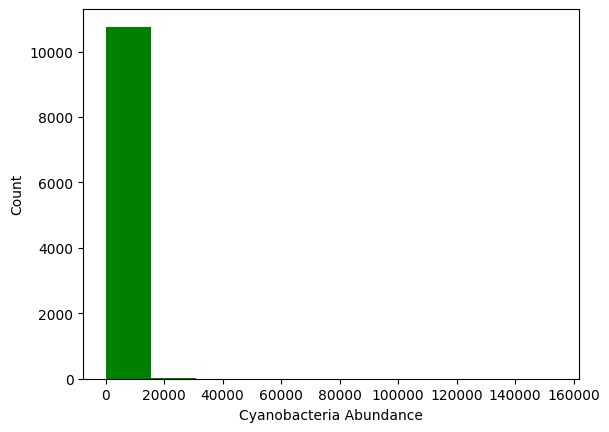

In [165]:
plt.hist(df["cyanobacteria_abundance"], color="green")
plt.xlabel("Cyanobacteria Abundance")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

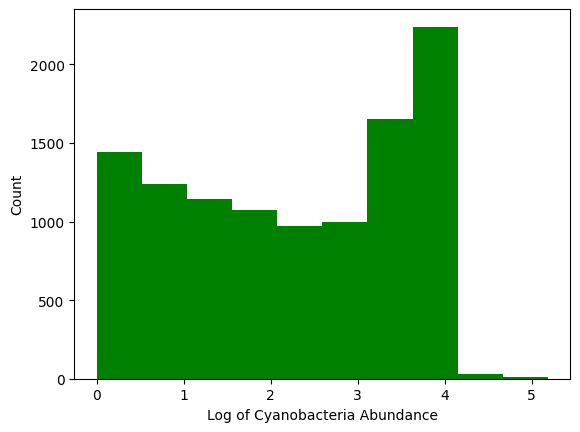

In [166]:
plt.hist(df["log_abundance"], color="green")
plt.xlabel("Log of Cyanobacteria Abundance")
plt.ylabel("Count")

# Estimating Model Potential and Tuning Hyperparameters with Spatial Cross-Validation

## Creating and Visualizing Folds

In [178]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "sample_date", "is_s2", "days_difference"]
X = df.drop(columns=drop_cols)
y = df["log_abundance"]

In [179]:
# create spatial groups
groups = (X["lat_binned"].astype(str) + "_" + X["lon_binned"].astype(str))

# bin y to create levels of log abundance values for stratified k folds
y_binned = pd.qcut(y, q=5, labels=False)

# set up splitter, create folds, assign each row to its fold index, create fold column for visualization
sgkf = StratifiedGroupKFold(n_splits=5)
fold_map = np.full(len(X), -1)
X["fold"] = -1
for i, (train_idx, test_idx) in enumerate(sgkf.split(X, y_binned, groups=groups)):
    fold_map[test_idx] = i
    X.loc[test_idx, "fold"] = i

# drop exact latitude and longitude
X_clean = X.drop(columns=["latitude", "longitude", "lat_binned", "lon_binned", "fold"])

# create a predefined split so the same folds are used in every search
ps = PredefinedSplit(test_fold=fold_map)

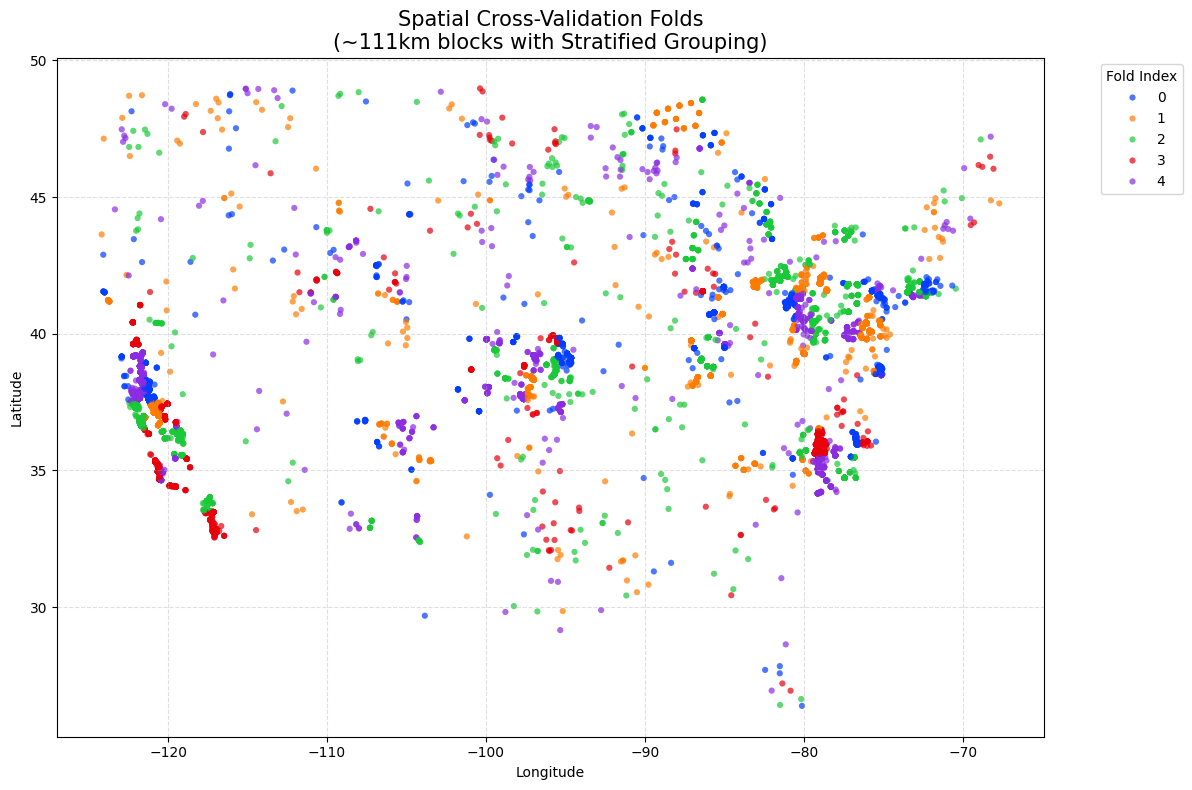

In [180]:
# visualization of folds
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=X, x="longitude", y="latitude", hue="fold", palette="bright", s=20, alpha=0.7, edgecolor="none")

plt.title("Spatial Cross-Validation Folds\n(~111km blocks with Stratified Grouping)", fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fold Index', bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## XGBoost

### Hyperparameter Tuning

In [219]:
# create grid of parameters to test
param_grid_xgb = {
    'max_depth': [3, 4, 5, 7],         
    'learning_rate': [0.01, 0.05],     # Slower learning is usually more robust
    'subsample': [0.6, 0.7, 0.8],      # Forced variety in training rows
    'colsample_bytree': [0.6, 0.7],    # Forced variety in training features (helps with correlation)
    'n_estimators': [500, 1000],       # With lower learning rates, you need more trees
    'reg_lambda': [1, 5, 10],          # L2 regularization (High values = more conservative)
    'reg_alpha': [0, 1, 5],            # L1 regularization (Can help "zero out" useless features)
    'gamma': [0, 0.1, 0.2, 0.5],       # Min loss reduction to create a new split
    'min_child_weight': [1, 5, 10]     # Minimum sum of instance weight needed in a child
}

In [220]:
# create and run search
search_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid_xgb,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

search_xgb.fit(X_clean, y)

# display results
xgb_params = search_xgb.best_params_
print(f"best score: {search_xgb.best_score_}")
print(f"best parameters: {xgb_params}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best score: 0.5790540078927211
best parameters: {'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.7}


### Results Analysis on Optimal Model

In [221]:
# display best model's scores for all folds
results_df = pd.DataFrame(search_xgb.cv_results_)

best_model_idx = search_xgb.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] for i in range(search_xgb.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.63126836 0.64728209 0.6055969  0.52656387 0.48455881]


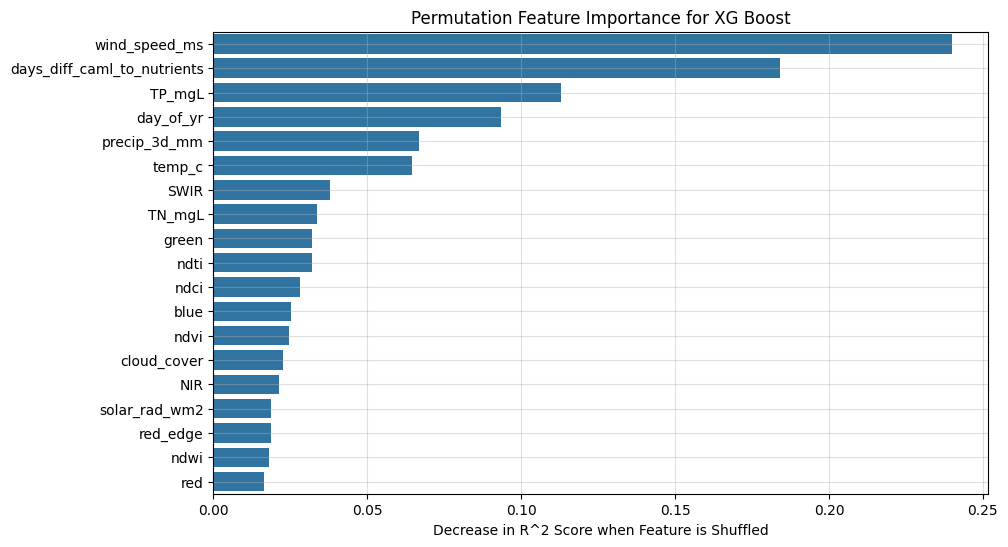

In [222]:
# feature importance plot for best model
xgb = search_xgb.best_estimator_

result = permutation_importance(
    xgb, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_rf = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_rf.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title("Permutation Feature Importance for XG Boost")
plt.xlabel("Decrease in R^2 Score when Feature is Shuffled")
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [284]:
# display rmse and mae for each fold
xgb_rmse = []
xgb_mae = []
all_preds = []
all_actual = []

for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = xgb.predict(X_test)
    preds_transformed = (10 ** preds) - 1

    all_preds.extend(preds)
    all_actual.extend(y_test)
        
    xgb_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
    xgb_mae.append(np.median(np.abs(y_test - preds_transformed)))

print(f"best model's rmse for each fold: {np.array(xgb_rmse)}")
print(f"best model's average rmse: {np.mean(xgb_rmse)}")
print(f"best model's median absolute error for each fold (transformed back into cells/mL): {np.array(xgb_mae)}")

best model's rmse for each fold: [0.47944197 0.50527774 0.51047774 0.50115991 0.6146587 ]
best model's average rmse: 0.5222032120293333
best model's median absolute error for each fold (transformed back into cells/mL): [249.38385887 234.63252364 239.3218687   20.5170759  194.75775605]


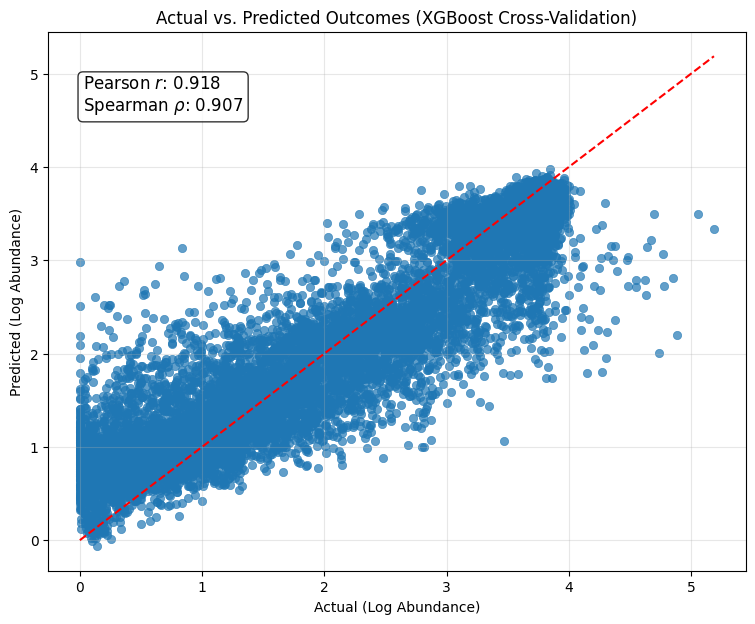

In [294]:
r, _ = pearsonr(all_actual, all_preds)
rho, _ = spearmanr(all_actual, all_preds)

plt.figure(figsize=(9, 7))
plt.scatter(all_actual, all_preds, alpha=0.7, linewidth=0.5)
plt.plot([min(all_actual), max(all_actual)], [min(all_actual), max(all_actual)], 'r--')

stats_text = f'Pearson $r$: {r:.3f}\nSpearman $\\rho$: {rho:.3f}'

plt.text(0.05, 0.92, stats_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title(f'Actual vs. Predicted Outcomes (XGBoost Cross-Validation)')
plt.xlabel('Actual (Log Abundance)')
plt.ylabel('Predicted (Log Abundance)')
plt.grid(alpha=0.3)
plt.show()

## Random Forest
### Hyperparameter Tuning

In [226]:
# create grid of parameters to test
param_grid_rf = {
    'n_estimators': [500],                  # 500 is usually plenty for RF stability
    'max_depth': [4, 6, 8, 10],             # Keep it shallow for better generalization
    'min_samples_split': [10, 20],          # Higher values = simpler trees
    'min_samples_leaf': [5, 10, 20],        # Prevents "tiny" specific rules
    'max_features': ['sqrt'],               # Forces the model to use all bands across different trees
    'max_samples': [0.6, 0.7, 0.8],         # NEW: The RF version of "subsample"
    'ccp_alpha': [0.0, 0.01, 0.1]           # NEW: Cost Complexity Pruning (The RF version of 'gamma')
}

In [227]:
# create and run search
search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

search_rf.fit(X_clean, y)

# display results
rf_params = search_rf.best_params_
print(f"best Score: {search_rf.best_score_}")
print(f"best Params: {rf_params}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.5470822996313991
best Params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': 10, 'ccp_alpha': 0.0}


### Results Analysis on Optimal Model

In [228]:
results_df = pd.DataFrame(search_rf.cv_results_)

best_model_idx = search_rf.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] 
               for i in range(search_rf.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.57831659 0.6116099  0.57471586 0.51544824 0.4553209 ]


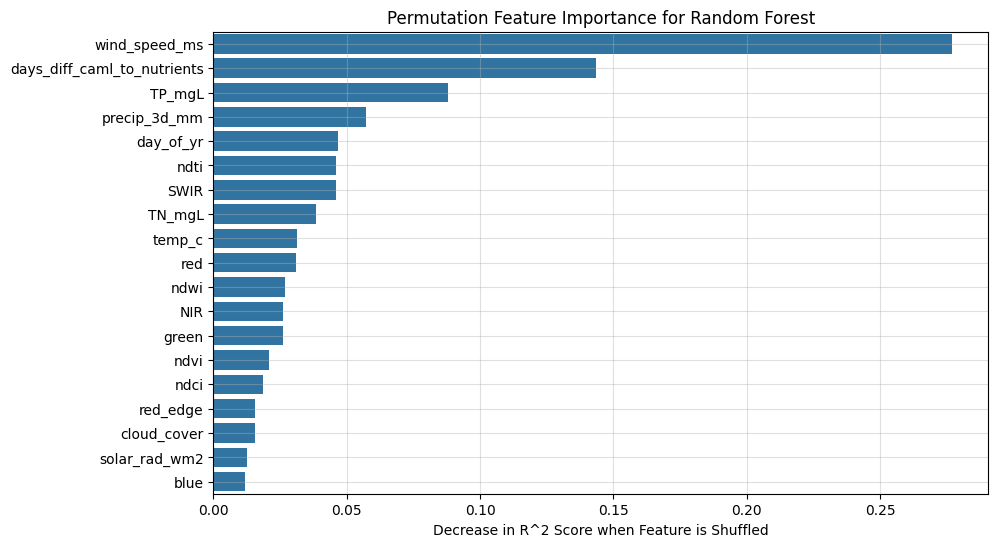

In [230]:
# feature importance plot for best model
rf = search_rf.best_estimator_

result = permutation_importance(
    rf, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_rf = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_rf.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title("Permutation Feature Importance for Random Forest")
plt.xlabel("Decrease in R^2 Score when Feature is Shuffled")
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [231]:
rf_rmse = []
rf_mae = []

for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = rf.predict(X_test)
    preds_transformed = (10 ** preds) - 1
        
    rf_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
    rf_mae.append(np.median(np.abs(y_test - preds_transformed)))

print(f"best model's rmse for each fold: {np.array(rf_rmse)}")
print(f"best model's average rmse: {np.mean(rf_rmse)}")
print(f"best model's median absolute error for each fold (transformed back into cells/mL): {np.array(rf_mae)}")

best model's rmse for each fold: [0.63094584 0.64525529 0.6660634  0.62641419 0.7657557 ]
best model's average rmse: 0.6668868845927285
best model's median absolute error for each fold (transformed back into cells/mL): [188.04968095 170.4899726  172.11431664  27.92820966 172.35190643]


## Histogram Gradient Boosting Regressor
### Hyperparameter Tuning

In [232]:
# create grid of parameters to try
param_grid_hgb = {
    'max_iter': [500, 1000],            # Higher iter with lower learning rate is better
    'max_depth': [3, 5, 7],             # Keep trees shallow for regional portability
    'learning_rate': [0.01, 0.05],      # Slow and steady learning
    'l2_regularization': [1, 10, 100],  # Stronger L2 helps with correlated bands
    'min_samples_leaf': [20, 50, 100],  # Prevents overfitting to specific outliers
    'max_leaf_nodes': [15, 31],         # Caps the complexity of each individual tree
    'max_features': [0.7, 0.8]          # Forces feature diversity (like XGB's colsample)
}

In [233]:
# create and run search
search_hgb = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_hgb,
    n_iter=50, 
    cv=ps,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

search_hgb.fit(X_clean, y)

# display results
hgb_params = search_hgb.best_params_
print(f"best Score: {search_hgb.best_score_}")
print(f"best Params: {hgb_params}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best Score: 0.578374981913983
best Params: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 1000, 'max_features': 0.8, 'max_depth': 7, 'learning_rate': 0.01, 'l2_regularization': 1}


### Results Analysis on Optimal Model

In [234]:
results_df = pd.DataFrame(search_hgb.cv_results_)

best_model_idx = search_hgb.best_index_
fold_scores = [results_df.loc[best_model_idx, f'split{i}_test_score'] for i in range(search_hgb.n_splits_)]

print(f"best model's scores for each fold: {np.array(fold_scores)}")

best model's scores for each fold: [0.63560199 0.64228522 0.59226457 0.54499835 0.47672478]


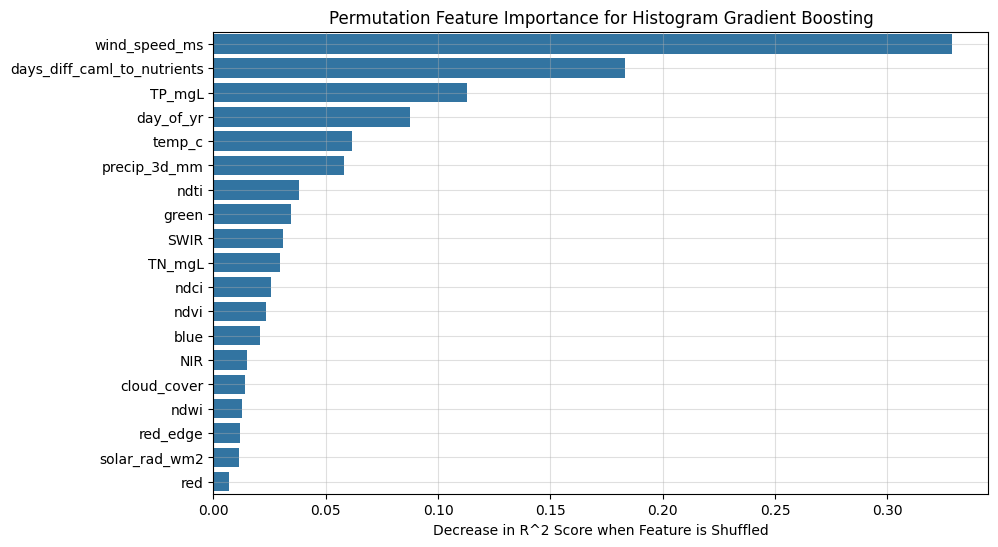

In [235]:
# feature importance plot for best model
hgb = search_hgb.best_estimator_

result = permutation_importance(
    hgb, 
    X_clean, y, 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(20), 
    x='importance_mean',
    y="feature"
)

plt.title('Permutation Feature Importance for Histogram Gradient Boosting')
plt.xlabel('Decrease in R^2 Score when Feature is Shuffled')
plt.ylabel("")
plt.grid(alpha=.4)
plt.show()

In [236]:
hgb_rmse = []
hgb_mae = []

for train_idx, test_idx in ps.split():
    X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
    preds = hgb.predict(X_test)
    preds_transformed = (10 ** preds) - 1
        
    hgb_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
    hgb_mae.append(np.median(np.abs(y_test - preds_transformed)))

print(f"best model's rmse for each fold: {np.array(hgb_rmse)}")
print(f"best model's average rmse: {np.mean(hgb_rmse)}")
print(f"best model's median absolute error for each fold (transformed back into cells/mL): {np.array(hgb_mae)}")

best model's rmse for each fold: [0.54470412 0.57527972 0.58371727 0.58046768 0.69784504]
best model's average rmse: 0.5964027642761212
best model's median absolute error for each fold (transformed back into cells/mL): [238.39316749 223.12370712 228.48814769  21.06027317 194.78204786]


# Evaluating Generalization with Out-of-Distribution Test Sets

In [198]:
# adding a state column to remove a state for testing
coords = list(zip(df['latitude'], df['longitude']))
results = rg.search(coords)

df['state'] = [res['admin1'] for res in results]

In [270]:
print(df["state"].value_counts())

state
California        4081
North Carolina    2398
Kansas             940
Pennsylvania       881
Indiana            521
Ohio               244
Connecticut        215
Delaware           184
Michigan           174
New York           169
Ontario            113
New Mexico         113
Wyoming             97
West Virginia       63
Wisconsin           56
Minnesota           55
Texas               36
South Dakota        33
North Dakota        26
Washington          25
Idaho               24
Virginia            21
Montana             21
New Jersey          20
Nebraska            19
South Carolina      19
Maryland            18
Oregon              17
Colorado            17
Utah                16
Maine               15
Oklahoma            15
New Hampshire       14
Georgia             13
Missouri            13
Florida             12
Mississippi         12
Nevada              10
Illinois            10
Iowa                10
Kentucky            10
Louisiana            9
Arizona              7
Massa

## Pacific Northwest

In [200]:
holdout_states_pnw = ["Washington", "Oregon", "Idaho", "Montana", "Wyoming"]
df_test = df[df['state'].isin(holdout_states_pnw)].copy()
df_train = df[~df['state'].isin(holdout_states_pnw)].copy()

In [201]:
df_test.shape

(184, 31)

In [202]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
X_test_pnw = df_test.drop(columns=drop_cols).reset_index(drop=True)
X_train_pnw = df_train.drop(columns=drop_cols).reset_index(drop=True)
y_test_pnw = df_test["log_abundance"].reset_index(drop=True)
y_train_pnw = df_train["log_abundance"].reset_index(drop=True)

In [203]:
results_pnw = pd.DataFrame(index=["xgb", "rf", "hgb"], columns=["r squared", "rmse", "mae", "rho"])

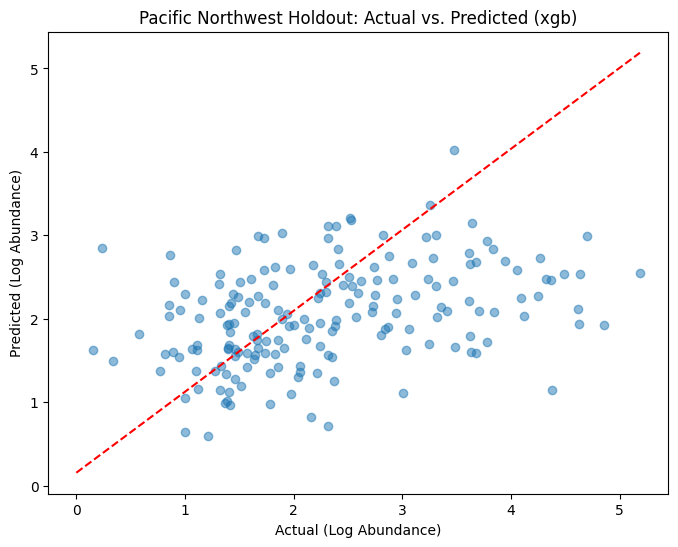

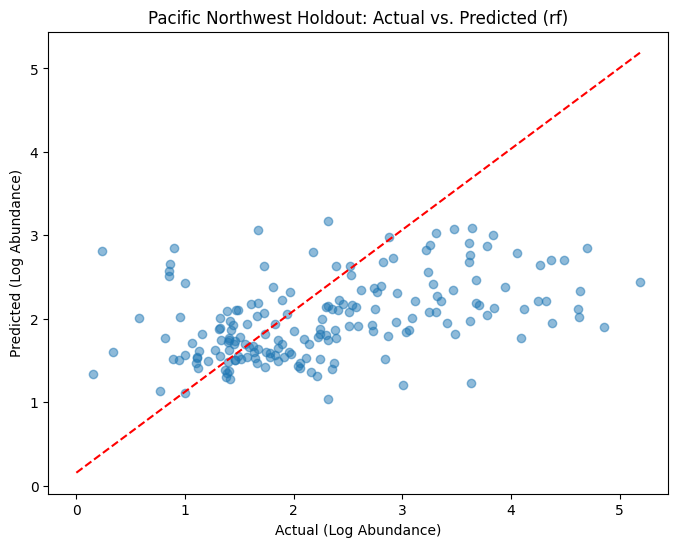

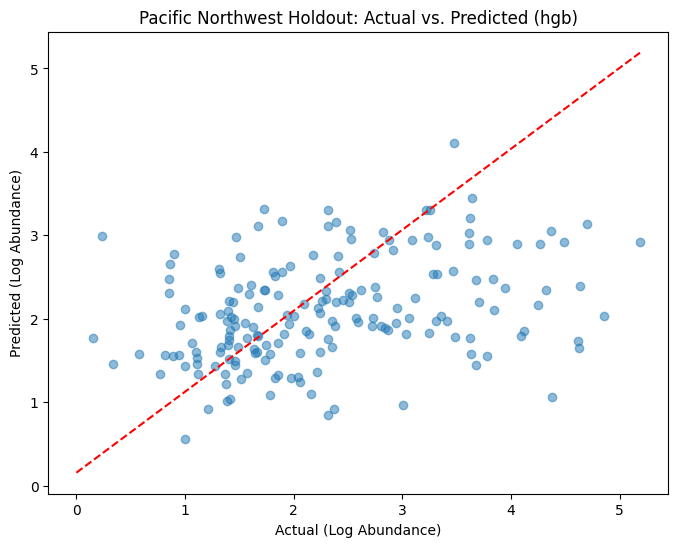

    r squared      rmse         mae       rho
xgb  0.048308   1.02997  109.624498  0.411127
rf   0.123872  0.988235   79.768108  0.491982
hgb  0.018051  1.046215  100.527743  0.364805


In [204]:
for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [xgb_params, rf_params, hgb_params]):

    model = function(**params)
    model.fit(X_train_pnw, y_train_pnw)

    preds = model.predict(X_test_pnw)
    preds_transformed = (10 ** preds) - 1

    results_pnw.loc[name, "r squared"] = model.score(X_test_pnw, y_test_pnw)
    results_pnw.loc[name, "rmse"] = np.sqrt(mean_squared_error(y_test_pnw, preds))
    results_pnw.loc[name, "mae"] = np.median(np.abs(y_test_pnw - preds_transformed))
    results_pnw.loc[name, "rho"] = spearmanr(y_test_pnw, preds)[0]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_pnw, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test_pnw.max()], [y_test_pnw.min(), y_test_pnw.max()], 'r--')
    plt.title(f'Pacific Northwest Holdout: Actual vs. Predicted ({name})')
    plt.xlabel('Actual (Log Abundance)')
    plt.ylabel('Predicted (Log Abundance)')
    plt.show()

print(results_pnw)


## Midwest

In [205]:
holdout_states_mw = ["Ohio", "Indiana", "Michigan", "Pennsylvania"]
df_test = df[df['state'].isin(holdout_states_mw)].copy()
df_train = df[~df['state'].isin(holdout_states_mw)].copy()

In [206]:
df_test.shape

(1820, 31)

In [207]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
X_test_mw = df_test.drop(columns=drop_cols).reset_index(drop=True)
X_train_mw = df_train.drop(columns=drop_cols).reset_index(drop=True)
y_test_mw = df_test["log_abundance"].reset_index(drop=True)
y_train_mw = df_train["log_abundance"].reset_index(drop=True)

In [208]:
results_mw = pd.DataFrame(index=["xgb", "rf", "hgb"], columns=["r squared", "rmse", "mae", "rho"])

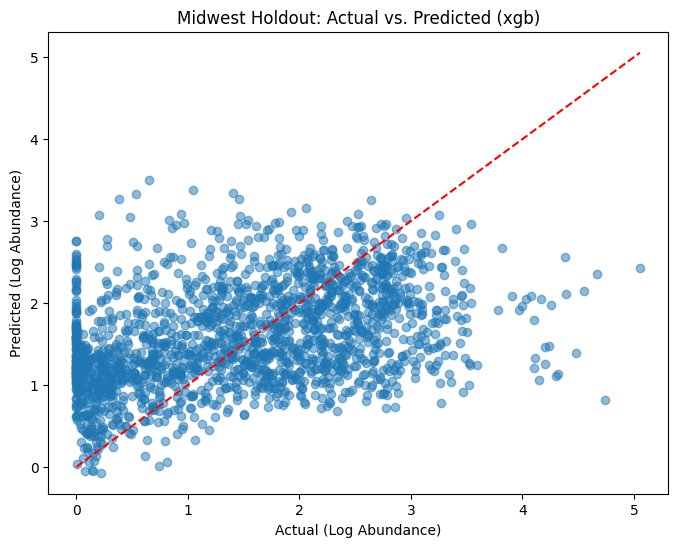

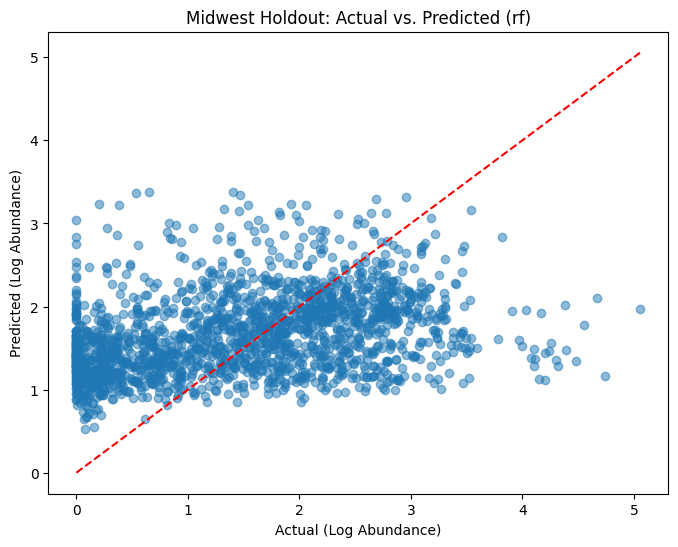

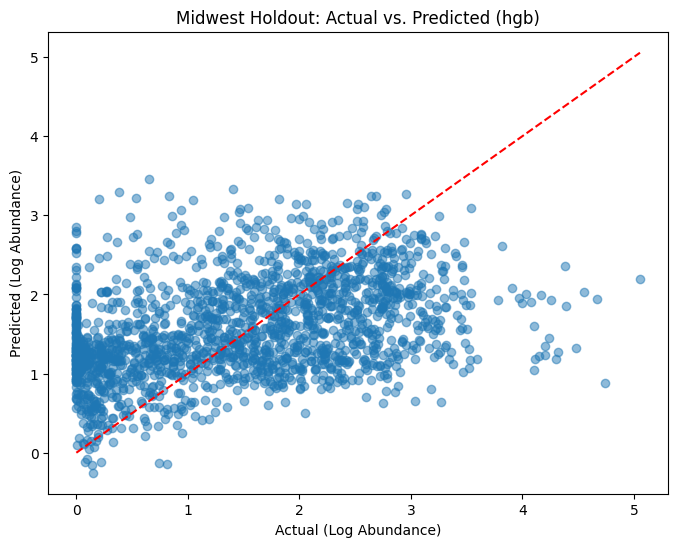

    r squared      rmse        mae       rho
xgb   0.12205  0.979705  29.930093  0.418364
rf   0.070063  1.008294  38.047425    0.3818
hgb  0.127686  0.976555   27.55841  0.426637


In [209]:
for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [xgb_params, rf_params, hgb_params]):

    model = function(**params)
    model.fit(X_train_mw, y_train_mw)

    preds = model.predict(X_test_mw)
    preds_transformed = (10 ** preds) - 1

    results_mw.loc[name, "r squared"] = model.score(X_test_mw, y_test_mw)
    results_mw.loc[name, "rmse"] = np.sqrt(mean_squared_error(y_test_mw, preds))
    results_mw.loc[name, "mae"] = np.median(np.abs(y_test_mw - preds_transformed))
    results_mw.loc[name, "rho"] = spearmanr(y_test_mw, preds)[0]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_mw, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test_mw.max()], [y_test_mw.min(), y_test_mw.max()], 'r--')
    plt.title(f'Midwest Holdout: Actual vs. Predicted ({name})')
    plt.xlabel('Actual (Log Abundance)')
    plt.ylabel('Predicted (Log Abundance)')
    plt.show()

print(results_mw)

## Northeast

In [210]:
holdout_states_ne = ["New York", "Connecticut", "Delaware", "Pennsylvania"]
df_test = df[df['state'].isin(holdout_states_ne)].copy()
df_train = df[~df['state'].isin(holdout_states_ne)].copy()

In [211]:
df_test.shape

(1449, 31)

In [212]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
X_test_ne = df_test.drop(columns=drop_cols).reset_index(drop=True)
X_train_ne = df_train.drop(columns=drop_cols).reset_index(drop=True)
y_test_ne = df_test["log_abundance"].reset_index(drop=True)
y_train_ne = df_train["log_abundance"].reset_index(drop=True)

In [213]:
results_ne = pd.DataFrame(index=["xgb", "rf", "hgb"], columns=["r squared", "rmse", "mae", "rho"])

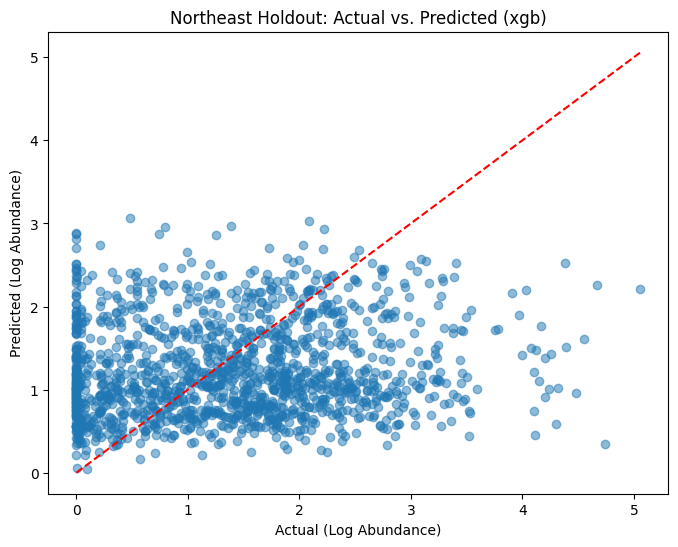

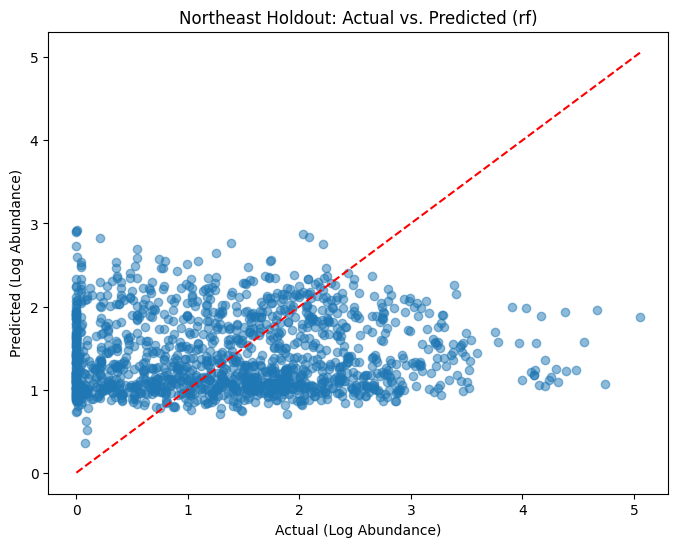

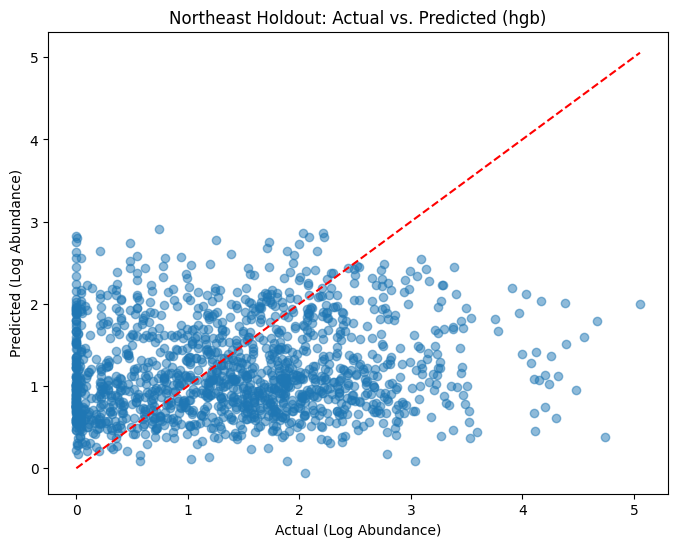

    r squared      rmse        mae       rho
xgb -0.202886  1.103261  10.451028  0.130137
rf  -0.171548  1.088795  16.444364  0.058493
hgb -0.214352  1.108507   9.524967  0.131537


In [214]:
for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [xgb_params, rf_params, hgb_params]):

    model = function(**params)
    model.fit(X_train_ne, y_train_ne)

    preds = model.predict(X_test_ne)
    preds_transformed = (10 ** preds) - 1

    results_ne.loc[name, "r squared"] = model.score(X_test_ne, y_test_ne)
    results_ne.loc[name, "rmse"] = np.sqrt(mean_squared_error(y_test_ne, preds))
    results_ne.loc[name, "mae"] = np.median(np.abs(y_test_ne - preds_transformed))
    results_ne.loc[name, "rho"] = spearmanr(y_test_ne, preds)[0]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_ne, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test_ne.max()], [y_test_ne.min(), y_test_ne.max()], 'r--')
    plt.title(f'Northeast Holdout: Actual vs. Predicted ({name})')
    plt.xlabel('Actual (Log Abundance)')
    plt.ylabel('Predicted (Log Abundance)')
    plt.show()

print(results_ne)